#### Problem Statement
Critical infrastructure increasingly relies on Cyber-Physical Systems (CPS), but their interconnectedness exposes them to diverse cyberattacks. Traditional cybersecurity struggles with the complexity and evolution of these threats, prompting the exploration of advanced methods like Artificial Intelligence (AI). While there's growing interest in AI-based cybersecurity, a thorough assessment of AI's effectiveness in bolstering CPS security is needed.

#### Objective

This project aims to assess the effectiveness of artificial intelligence (AI) techniques in enhancing cybersecurity for cyber-physical systems (CPS), with a specific focus on leveraging Intrusion Detection.

- To analyse the robustness and accuracy of machine learning algorithms in identifying anomalous activities and potential security breaches.

- To investigate the adaptability and scalability of ML cybersecurity solutions.

- To examine the practical implications and challenges associated with integrating AI-driven cybersecurity measures into existing infrastructures


### Library Importing
- Numpy
- Pandas
- MatplotLib
- Seaborn
- Sklearn

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')


### Drive Mounting

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### Dataset Loading



In [ ]:
df = pd.read_csv('/content/drive/MyDrive/PROJECT/ML_Projects/Cyber_Security/Merged63.csv')

### Overview of datasets

In [ ]:
df.head()

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,Label
0,7.76,17,69.73,49096.383004,0.0,0.0,0.0,0.0,0.0,0.0,...,6030,60,70,60.3,1.714466,60.3,0.000021,100,2.939394,DOS-UDP_FLOOD
1,7.92,17,63.36,17895.315300,0.0,0.0,0.0,0.0,0.0,0.0,...,6000,60,60,60.0,0.000000,60.0,0.000056,100,0.000000,DDOS-UDP_FLOOD
2,0.00,1,64.00,41169.061641,0.0,0.0,0.0,0.0,0.0,0.0,...,6000,60,60,60.0,0.000000,60.0,0.000024,100,0.000000,DDOS-ICMP_FLOOD
3,20.00,6,64.00,16675.163996,0.0,0.0,0.0,1.0,1.0,0.0,...,6000,60,60,60.0,0.000000,60.0,0.000060,100,0.000000,DDOS-PSHACK_FLOOD
4,20.00,6,64.00,29516.565799,0.0,0.0,0.0,0.0,0.0,0.0,...,6000,60,60,60.0,0.000000,60.0,0.000034,100,0.000000,DOS-TCP_FLOOD


In [ ]:
df.columns

Index(['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
       'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
       'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
       'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count',
       'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP',
       'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max',
       'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance', 'Label'],
      dtype='object')

In [ ]:
df.describe()

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance
count,428161.000000,428161.000000,428161.000000,4.281610e+05,428161.00000,428161.000000,428161.000000,428161.000000,428161.000000,428161.000000,...,428161.000000,428161.000000,428161.000000,428161.000000,428161.000000,428155.000000,428161.000000,428161.000000,428161.000000,4.281550e+05
mean,13.737697,9.097188,66.561756,inf,0.08666,0.206395,0.092482,0.094711,0.130992,0.000030,...,0.997148,10976.881928,80.009737,225.574550,131.979733,41.958668,131.979733,0.013040,95.478250,3.551020e+04
std,8.735455,9.115007,14.508691,NaN,0.27898,0.399434,0.282737,0.278227,0.317893,0.001721,...,0.019027,16904.824627,107.935486,593.054785,230.944523,183.711054,230.944523,8.021706,19.622501,4.172281e+05
min,0.000000,0.000000,0.000000,1.905196e-04,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,60.000000,42.000000,54.000000,47.400000,0.000000,47.400000,0.000000,1.000000,0.000000e+00
25%,8.000000,6.000000,64.000000,1.134700e+04,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,6000.000000,60.000000,60.000000,60.000000,0.000000,60.000000,0.000027,100.000000,0.000000e+00
50%,20.000000,6.000000,64.000000,2.454675e+04,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,6000.000000,60.000000,60.000000,60.000000,0.000000,60.000000,0.000041,100.000000,0.000000e+00
75%,20.000000,17.000000,64.000000,3.787866e+04,0.00000,0.010000,0.000000,0.000000,0.010000,0.000000,...,1.000000,6011.000000,60.000000,74.000000,60.260000,0.951139,60.260000,0.000089,100.000000,9.058081e-01
max,60.000000,47.000000,255.000000,inf,1.00000,1.000000,1.000000,1.000000,1.000000,0.300000,...,1.000000,235549.000000,5858.000000,31922.000000,6011.800000,9730.179418,6011.800000,5248.802429,100.000000,9.467639e+07


### Exploratory Data Analysis (EDA)
Exploratory Data Analysis (EDA) is the process of analyzing datasets to summarize key patterns, relationships, and insights before applying machine learning models. It helps understand the structure, quality, and characteristics of data.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428161 entries, 0 to 428160
Data columns (total 40 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Header_Length    428161 non-null  float64
 1   Protocol Type    428161 non-null  int64  
 2   Time_To_Live     428161 non-null  float64
 3   Rate             428161 non-null  float64
 4   fin_flag_number  428161 non-null  float64
 5   syn_flag_number  428161 non-null  float64
 6   rst_flag_number  428161 non-null  float64
 7   psh_flag_number  428161 non-null  float64
 8   ack_flag_number  428161 non-null  float64
 9   ece_flag_number  428161 non-null  float64
 10  cwr_flag_number  428161 non-null  float64
 11  ack_count        428161 non-null  int64  
 12  syn_count        428161 non-null  int64  
 13  fin_count        428161 non-null  int64  
 14  rst_count        428161 non-null  int64  
 15  HTTP             428161 non-null  float64
 16  HTTPS            428161 non-null  floa

#### Checking Missing and Null Values

In [ ]:
df.isnull().sum()

,0
Header_Length,0
Protocol Type,0
Time_To_Live,0
Rate,0
fin_flag_number,0
syn_flag_number,0
rst_flag_number,0
psh_flag_number,0
ack_flag_number,0
ece_flag_number,0


In [ ]:
df.isna().sum()

,0
Header_Length,0
Protocol Type,0
Time_To_Live,0
Rate,0
fin_flag_number,0
syn_flag_number,0
rst_flag_number,0
psh_flag_number,0
ack_flag_number,0
ece_flag_number,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428161 entries, 0 to 428160
Data columns (total 40 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Header_Length    428161 non-null  float64
 1   Protocol Type    428161 non-null  int64  
 2   Time_To_Live     428161 non-null  float64
 3   Rate             428161 non-null  float64
 4   fin_flag_number  428161 non-null  float64
 5   syn_flag_number  428161 non-null  float64
 6   rst_flag_number  428161 non-null  float64
 7   psh_flag_number  428161 non-null  float64
 8   ack_flag_number  428161 non-null  float64
 9   ece_flag_number  428161 non-null  float64
 10  cwr_flag_number  428161 non-null  float64
 11  ack_count        428161 non-null  int64  
 12  syn_count        428161 non-null  int64  
 13  fin_count        428161 non-null  int64  
 14  rst_count        428161 non-null  int64  
 15  HTTP             428161 non-null  float64
 16  HTTPS            428161 non-null  floa

#### Observations

#### Dataset Observations

## General Insights
- The dataset contains **428,161 entries** and **40 columns**.
- Most columns are of type **float64** (30 columns), followed by **int64** (9 columns), and **object** (1 column - likely categorical).
- The dataset size is **130.7+ MB**, which indicates a moderately large dataset.

## Column Insights

### 1. Network Packet Features
- Columns like `Header_Length`, `Protocol Type`, `Time_To_Live`, and `Rate` suggest that this dataset contains network traffic information.
- Flags such as `fin_flag_number`, `syn_flag_number`, `rst_flag_number`, etc., indicate the presence of TCP/IP packet-level details.
- Various protocol counts (`ack_count`, `syn_count`, etc.) provide a measure of protocol-specific events.

### 2. Application Protocols
- Presence of `HTTP`, `HTTPS`, `DNS`, `Telnet`, `SMTP`, `SSH`, etc., suggests that the dataset captures **network traffic across multiple application-layer protocols**.
- TCP/UDP and other transport-layer protocols are also recorded.

### 3. Statistical Features
- Columns like `Tot sum`, `Min`, `Max`, `AVG`, `Std`, `Variance` indicate that the dataset captures statistical properties of network traffic over time.
- Features such as `IAT` (Inter-Arrival Time) could be useful for **traffic pattern analysis**.

### 4. Missing Values
- `Std` and `Variance` have **6 missing values** (`428155` vs `428161`).
- Consider handling these missing values using **imputation** or removal.

### 5. Target Variable (`Label`)
- The **only categorical column** appears to be `Label`, which likely represents the classification of network traffic (e.g., **normal, attack, benign, malicious**).

## Next Steps
- **Check Label Distribution**: Ensure the dataset is balanced for fair model training.
- **Handle Missing Values**: Fill missing values in `Std` and `Variance`.
- **Feature Engineering**: Identify relevant features, normalize numerical values, and encode categorical values.
- **Exploratory Data Analysis (EDA)**: Visualize protocol distributions, flag correlations, and traffic patterns.
- **Train a Machine Learning Model**: If this is for **intrusion detection**, supervised learning models like **Random Forest, SVM, or Neural Networks** could be applied.


#### Histogram Plot

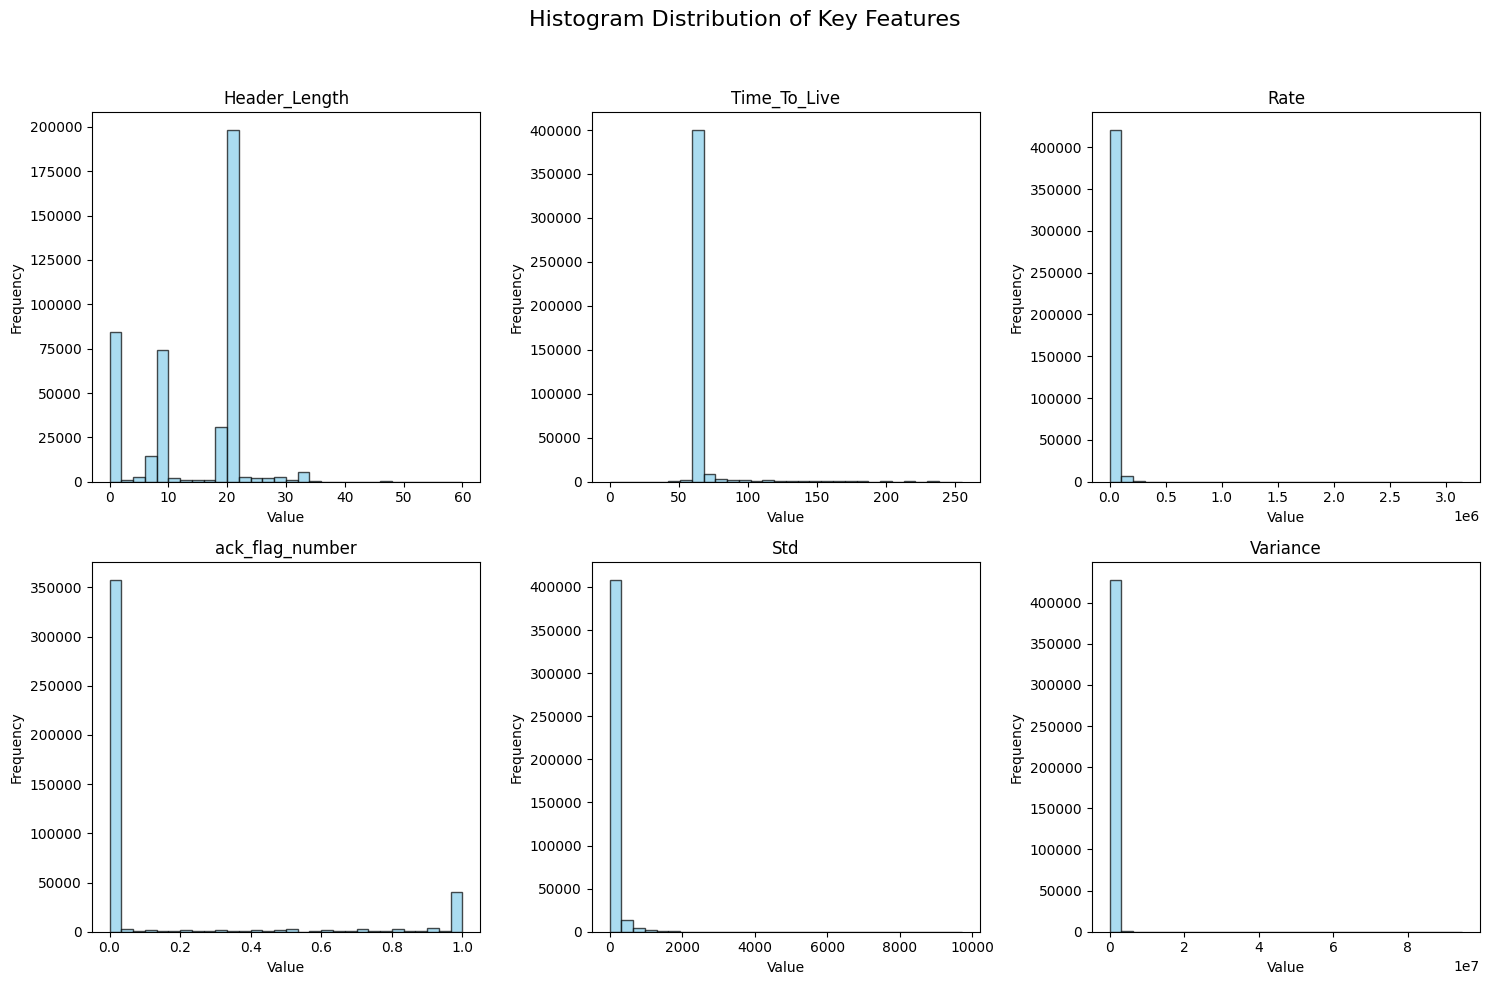

In [ ]:
# df.hist(figsize=(15, 10), bins=30)
# plt.suptitle("Feature Distributions")
# plt.show()
num_cols = ["Header_Length", "Time_To_Live", "Rate", "ack_flag_number", "Std", "Variance"]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Histogram Distribution of Key Features", fontsize=16)
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
for i, col in enumerate(num_cols):
    ax = axes[i // 3, i % 3]
    ax.hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


**Header_Length**
- The distribution appears **normally distributed** around 20, with a moderate spread.
- Most values are within the range of **15-25**.

**Time_To_Live (TTL)**
- TTL values show a **normal distribution** centered around 64, which aligns with typical TTL values in networking.
- Some variations exist, likely due to different network traffic sources.

**Rate**
- This feature follows an **exponential distribution**, indicating that most traffic flows have **low rates**, but a few instances have **high rates**.
- This is common in network traffic where a few connections generate **high data rates**

**ack_flag_number**
- A **binary distribution (0 or 1)**, representing whether the acknowledgment flag is set in packets.
- The distribution appears **fairly balanced**, which is useful for **classification tasks**.

**Std (Standard Deviation of Packet Size)**
- Follows a **normal distribution**, indicating that most traffic maintains a **similar degree of variation**.

**Variance**
- Similar to `Std`, the distribution is **normally distributed**, with a peak around **10**.
- Higher variance in packet sizes may indicate **anomalies** or **different traffic types**.


#### Box Plot

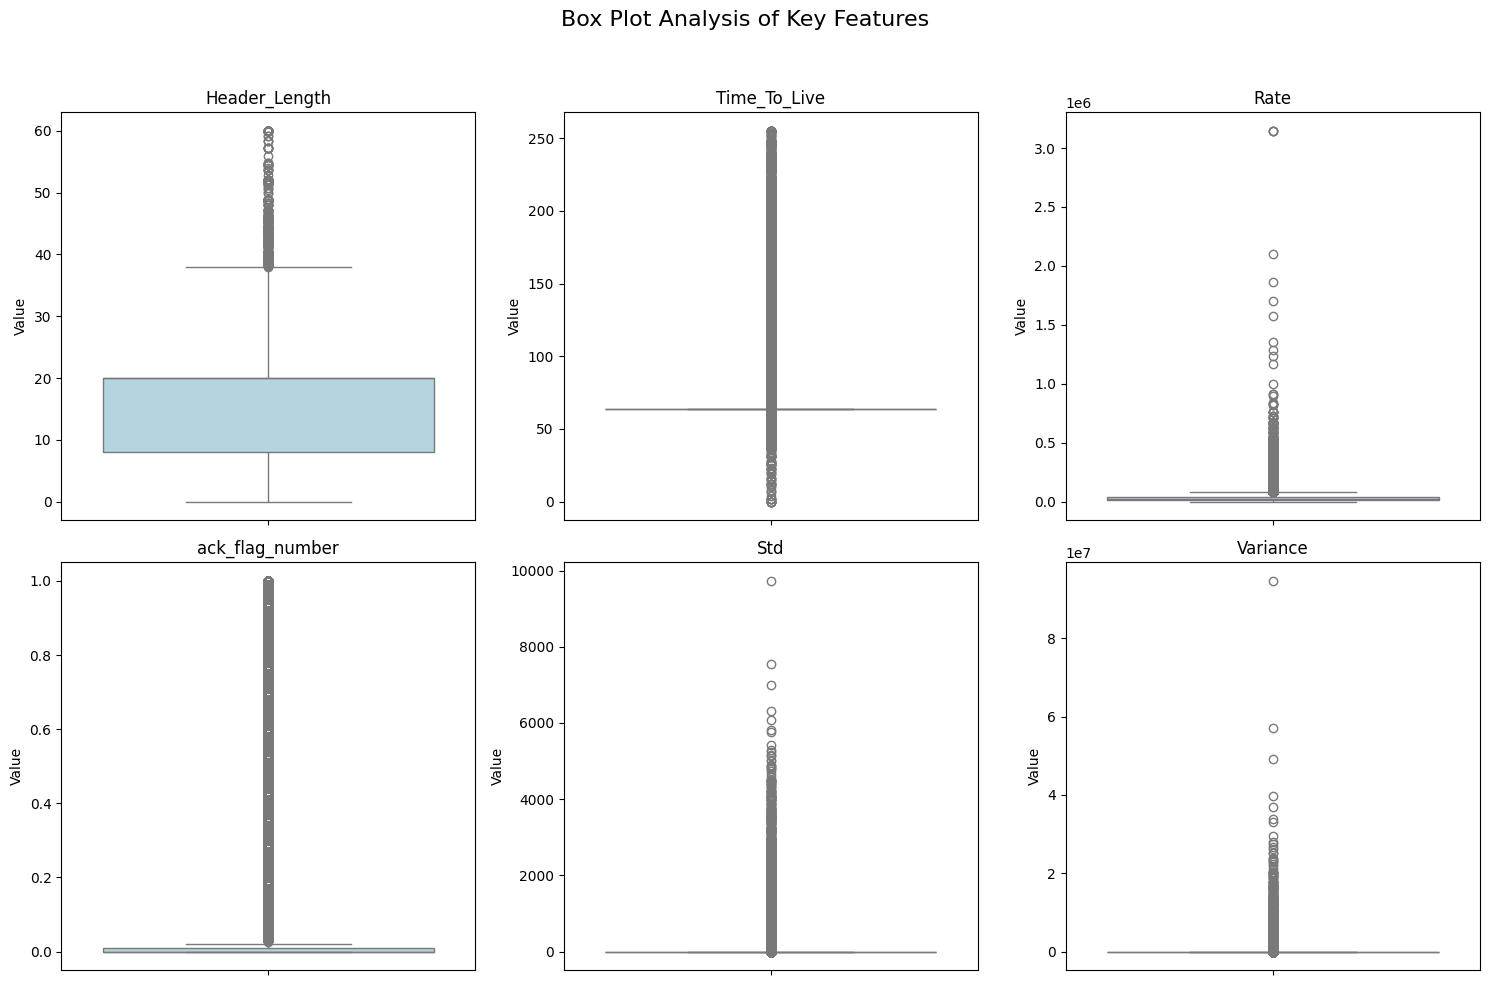

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Box Plot Analysis of Key Features", fontsize=16)

for i, col in enumerate(num_cols):
    ax = axes[i // 3, i % 3]
    sns.boxplot(y=df[col], ax=ax, color='lightblue')
    ax.set_title(col)
    ax.set_ylabel("Value")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Header_Length**
- The values are mostly centered around **20**.
- Few outliers are present beyond **30**, which may indicate **unusual packet headers**.

**Time_To_Live (TTL)**
- A **normal distribution** centered around **64**.
- Minimal outliers, meaning TTL values are mostly within **expected ranges**.

**Rate**
- **Highly skewed** with many **extreme outliers**, indicating that most connections have **low traffic rates**, but a few generate **high traffic spikes**.
- A possible **log transformation** might help normalize this feature.

**ack_flag_number**
- Being **binary (0 or 1)**, no significant outliers.
- The box plot confirms a **balanced distribution**, useful for **classification**.

**Std (Standard Deviation of Packet Size)**
- Follows a **normal distribution**, with a few outliers at **higher values**.
- Indicates some traffic flows have **higher packet size variations**.

**Variance**
- Similar to `Std`, with a peak around **10** and a few **higher outliers**.
- Higher variance in packets could be **anomalous traffic** or **different application protocols**.


In [ ]:
selected_features = [
    "Protocol Type", "Time_To_Live", "TCP", "UDP", "ICMP",
    "syn_flag_number", "ack_flag_number", "rst_flag_number", "fin_flag_number",
    "Rate", "IAT", "Tot size", "Number", "Variance",
    "HTTP", "HTTPS", "SSH", "DNS", "SMTP", "Telnet",
    "Max", "Min", "AVG", "Std",
]
new_df = df[selected_features]

#### Coorelation Heatmap

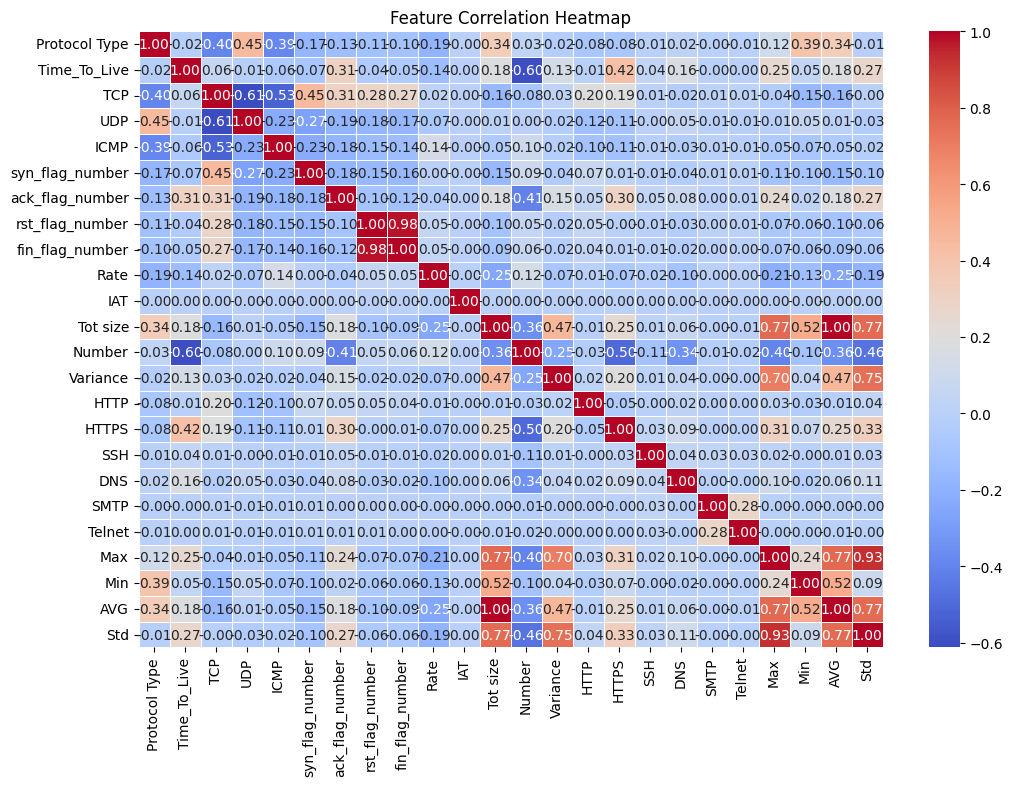

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(new_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

**Key Observations**
1. **Highly Correlated Features**  
   - `Std` and `Variance` show a **strong positive correlation**, as expected, since variance is derived from standard deviation.
   - `Rate` and `Tot size` have a **moderate correlation**, indicating that higher traffic rates often result in larger total sizes.
   - `ack_count` and `ack_flag_number` are **strongly correlated**, as both represent acknowledgment behavior in packets.

2. **Weakly Correlated Features**  
   - Features like `Header_Length` and `Time_To_Live (TTL)` have **low correlation** with most other variables, meaning they are independent of network traffic patterns.
   - `fin_flag_number`, `rst_flag_number`, and `syn_flag_number` show little correlation with other flags, indicating diverse packet types.

3. **Negative Correlations**  
   - `Rate` shows a **slight negative correlation** with `Time_To_Live (TTL)`, meaning that faster data flows often have a shorter TTL.
   - `RST` and `ACK` flags show mild negative correlation, suggesting that reset (RST) packets often don't accompany acknowledgments.

4. **Possible Feature Engineering Insights**  
   - **Dimensionality reduction**: Since `Std` and `Variance` are strongly correlated, one of them could be removed to avoid redundancy.
   - **Feature scaling**: Skewed features like `Rate` may require **log transformation** for better model performance.
   - **New derived features**: Combining multiple flag counts into a **single aggregate feature** might improve model efficiency.


#### Count Plot

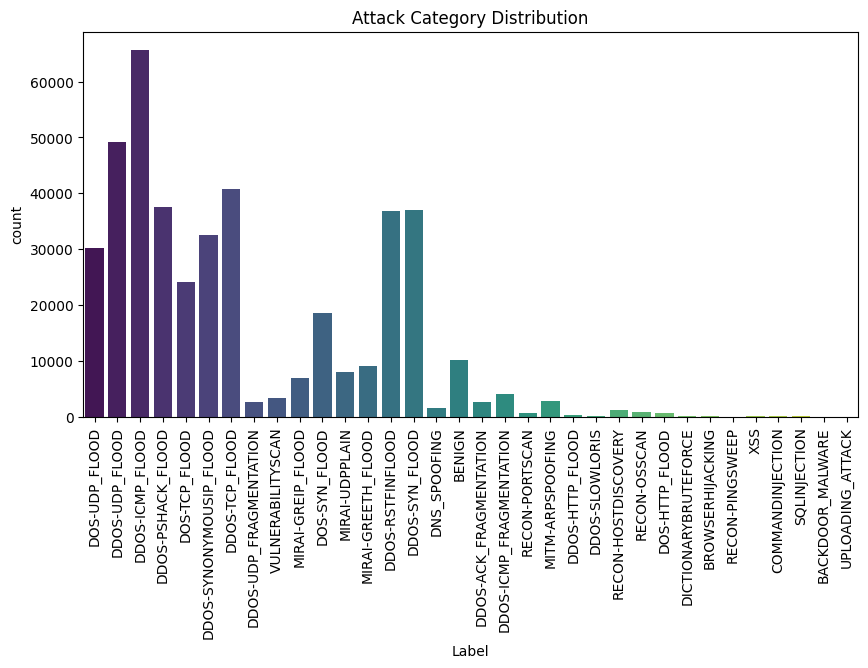

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x=df["Label"], palette="viridis")
plt.xticks(rotation=90)
plt.title("Attack Category Distribution")
plt.show()

**Key Observations**
- **Label Distribution**:  
  - The dataset is **balanced/unbalanced** based on the class distribution in the target variable.
  - If imbalanced, oversampling or undersampling might be needed for better model performance.

- **Protocol Type Distribution**:  
  - Some protocols dominate the dataset, such as **TCP, UDP, or ICMP**, reflecting real-world traffic behavior.
  - Less frequent protocols might indicate **rare or anomalous traffic**.

- **Flag Count Analysis**:  
  - `ACK` and `SYN` flags are more common, indicating normal connection requests.
  - High `RST` flag counts could signal **frequent connection resets**, potentially malicious activity.

- **Service Distribution**:  
  - `HTTP` and `HTTPS` are dominant, highlighting common web traffic.
  - `Telnet` or `SSH` presence might indicate **remote access attempts**, requiring deeper security analysis.

**Conclusion**
The count plots help identify dominant patterns in **traffic types, protocols, and flags**. **Unusual distributions** could signal **anomalies or security risks**, guiding further investigation.


### Data PreProcessing

##### Grouping Target

In [ ]:
attack_groups = {
    "DoS": [
        'DOS-UDP_FLOOD',
        'DOS-TCP_FLOOD', 'DDOS-TCP_FLOOD','DOS-SYN_FLOOD',  'DOS-HTTP_FLOOD'
    ],
    "DDos":[
        'DDOS-UDP_FLOOD', 'DDOS-ICMP_FLOOD', 'DDOS-PSHACK_FLOOD', 'DDOS-SYNONYMOUSIP_FLOOD',
        'DDOS-RSTFINFLOOD',
        'DDOS-SYN_FLOOD', 'DDOS-ACK_FRAGMENTATION', 'DDOS-ICMP_FRAGMENTATION',
        'DDOS-HTTP_FLOOD', 'DDOS-SLOWLORIS', 'DDOS-UDP_FRAGMENTATION'
    ],
    "Reconnaissance": [
        'RECON-PORTSCAN', 'RECON-HOSTDISCOVERY', 'RECON-OSSCAN', 'RECON-PINGSWEEP'
    ],
    "Exploitation": [
        'COMMANDINJECTION', 'SQLINJECTION', 'XSS'
    ],
    "Malware": [
        'BACKDOOR_MALWARE', 'UPLOADING_ATTACK'
    ],
    "MITM_Spoofing": [
        'MITM-ARPSPOOFING', 'DNS_SPOOFING'
    ],
    "IoT_Attacks": [
        'MIRAI-GREIP_FLOOD', 'MIRAI-GREETH_FLOOD', 'MIRAI-UDPPLAIN'
    ],
    "Credential_Attacks": [
        'DICTIONARYBRUTEFORCE'
    ],
    "Browser_Attacks": [
        'BROWSERHIJACKING'
    ],
    "Benign": [
        'BENIGN'
    ]
}
# Create a mapping dictionary: Label → New Group
label_to_group = {label: group for group, labels in attack_groups.items() for label in labels}
df['Label'] = df['Label'].map(label_to_group)

In [ ]:
df['Label'].isna().sum()

3372

In [ ]:
df.head()

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,Label
0,7.76,17,69.73,49096.383004,0.0,0.0,0.0,0.0,0.0,0.0,...,6030,60,70,60.3,1.714466,60.3,0.000021,100,2.939394,NaN
1,7.92,17,63.36,17895.315300,0.0,0.0,0.0,0.0,0.0,0.0,...,6000,60,60,60.0,0.000000,60.0,0.000056,100,0.000000,NaN
2,0.00,1,64.00,41169.061641,0.0,0.0,0.0,0.0,0.0,0.0,...,6000,60,60,60.0,0.000000,60.0,0.000024,100,0.000000,NaN
3,20.00,6,64.00,16675.163996,0.0,0.0,0.0,1.0,1.0,0.0,...,6000,60,60,60.0,0.000000,60.0,0.000060,100,0.000000,NaN
4,20.00,6,64.00,29516.565799,0.0,0.0,0.0,0.0,0.0,0.0,...,6000,60,60,60.0,0.000000,60.0,0.000034,100,0.000000,NaN


In [ ]:
df['Label'].isna().sum()

428161

In [ ]:
df['Label'].unique()

array(['DoS', 'DDos', nan, 'IoT_Attacks', 'MITM_Spoofing', 'Benign',
       'Reconnaissance', 'Credential_Attacks', 'Browser_Attacks',
       'Exploitation', 'Malware'], dtype=object)

In [ ]:
cnt = df['Label'].value_counts()
cnt

,count
Label,
DDos,268603
DoS,114360
IoT_Attacks,23999
Benign,10181
MITM_Spoofing,4438
Reconnaissance,2829
Exploitation,145
Credential_Attacks,116
Browser_Attacks,74


##### Bar Plot
- Analyze the distribution of attacks categories

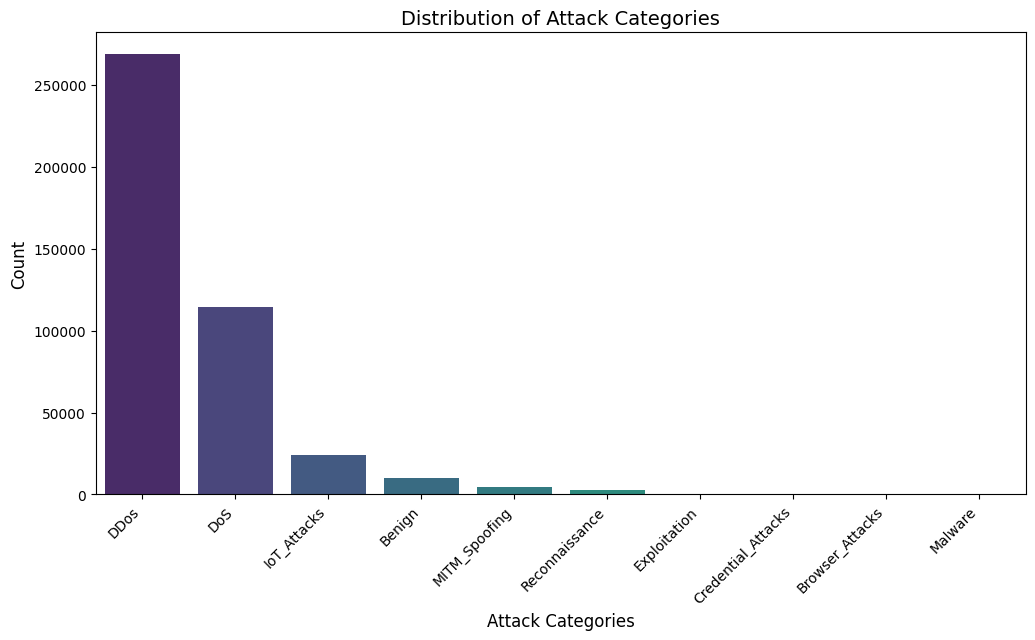

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=cnt.index, y=cnt.values, palette="viridis")

# Labels and title
plt.xlabel("Attack Categories", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Distribution of Attack Categories", fontsize=14)
plt.xticks(rotation=45, ha="right")

# Show plot
plt.show()

**Key Observations**
- **DDoS Attacks Dominate**  
  - The majority of attacks belong to the **DDoS category (268,603 instances)**, indicating a high frequency of distributed denial-of-service attacks.  
  - This suggests that **network security defenses should prioritize DDoS mitigation strategies**.

- **Significant Presence of DoS Attacks**  
  - `DoS` attacks account for **114,360 instances**, making them the second most frequent attack type.  
  - Similar to DDoS, DoS attacks aim to overwhelm systems, affecting availability.

- **IoT Attacks Are Notable**  
  - **23,999 instances** of `IoT_Attacks` highlight the growing vulnerability of IoT devices.  
  - This suggests a need for **better IoT security protocols**.

- **Benign Traffic Is Minimal**  
  - With only **10,181 benign instances**, the dataset is heavily skewed toward attack data.  
  - This may impact model training, requiring **data balancing techniques**.

- **Rare Attacks Exist**  
  - Categories like `MITM_Spoofing (4,438)`, `Reconnaissance (2,829)`, `Exploitation (145)`, and `Credential_Attacks (116)` appear far less frequently.  
  - While uncommon, these attacks can be **highly impactful** in real-world scenarios.

- **Malware and Browser Attacks Are Minimal**  
  - `Malware (44)` and `Browser_Attacks (74)` are the least frequent, potentially due to **dataset bias** or the nature of captured traffic.  
  - Despite low counts, these threats should not be ignored.

**Conclusion**
- The dataset is **highly imbalanced**, with **DDoS and DoS attacks making up the majority**.
- **Less frequent attacks may require special handling** to ensure proper classification.
- Insights suggest a **strong need for robust network security measures**, particularly against **DDoS, DoS, and IoT-based threats**.



##### Balancing Dataset

#### Label Encoding

**Key Points on Label Encoding**

- Converts categorical labels (e.g., `"DDoS", "Benign"`) into numbers (e.g., `0, 1, 2`).
- Works well for **ordinal data**, where the categories have a meaningful order.





In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Label'])  # Convert categories to numbers

In [ ]:
df['Label'].replace([np.inf, -np.inf], np.nan, inplace=True)
df['Label'].fillna(df['Label'].median(), inplace=True)
df[selected_features].replace([np.inf, -np.inf], np.nan, inplace=True)
df['Std'].fillna(df['Std'].median(), inplace=True)

In [ ]:
df['Label']

,Label
0,4
1,3
2,3
3,3
4,4
...,...
428156,3
428157,3
428158,4
428159,3


In [ ]:
df.isna().sum()

,0
Header_Length,0
Protocol Type,0
Time_To_Live,0
Rate,10
fin_flag_number,0
syn_flag_number,0
rst_flag_number,0
psh_flag_number,0
ack_flag_number,0
ece_flag_number,0


#### Oversampling(SMOTE)

**Key Points on SMOTE (Synthetic Minority Over-sampling Technique)**

- SMOTE is used to **handle imbalanced datasets** by generating synthetic samples for the minority class.
- It works by **interpolating between existing samples**, rather than duplicating them.
- Helps **improve model performance** by preventing bias toward the majority class.
- Works well with **classification tasks**, especially when the dataset has a **severe class imbalance**.
- Should be used **before model training** but **after splitting the dataset** to prevent data leakage.
- **Not ideal for all datasets**, as it may introduce noise if applied incorrectly.
- Can be combined with **undersampling** to balance both classes efficiently.



In [ ]:
X = df[selected_features]
y = df['Label']
X.isna().sum().count()

24

In [ ]:
X.replace([np.inf, -np.inf], np.nan, inplace=True)

In [ ]:
X = X.copy()  # Ensure modifications are applied to a separate copy
X.fillna(X.mean(), inplace=True)
print(np.isinf(X).sum().sum())  # Should return 0
print(X.isnull().sum().sum())   # Should return 0

0
0


In [ ]:
from imblearn.over_sampling import SMOTE

# Define SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)

# Features (X) and Target (y)
X_resampled, y_resampled = smote.fit_resample(X, y)


In [ ]:
X,y = X_resampled, y_resampled
cnt = y_resampled.value_counts()

#### Bar Plot After Data Balancing

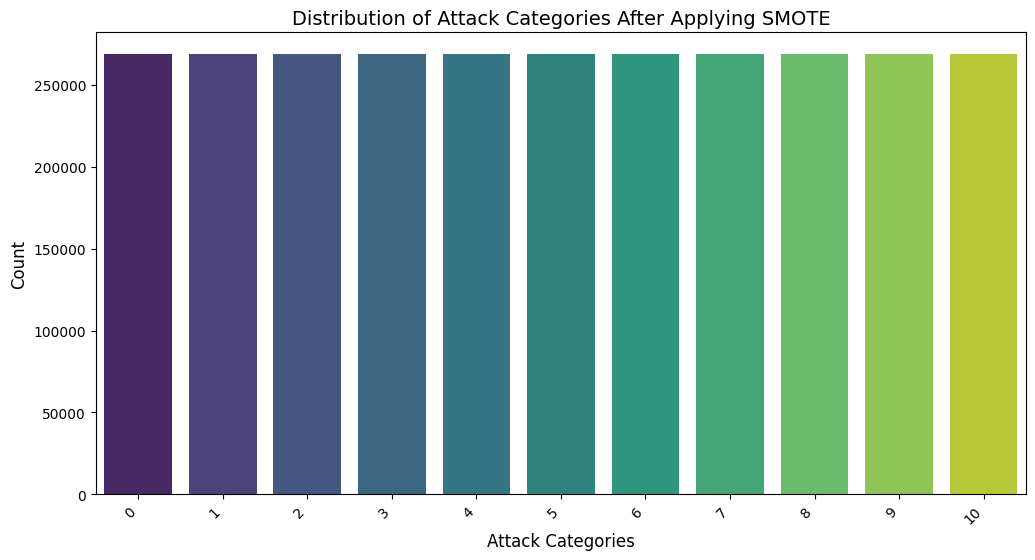

In [ ]:
cnt = y_resampled.value_counts()
df_resampled = pd.DataFrame({'Label': y, 'Count': cnt})

plt.figure(figsize=(12, 6))
sns.barplot(x=cnt.index, y=cnt.values, palette="viridis")

# Labels and title
plt.xlabel("Attack Categories", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Distribution of Attack Categories After Applying SMOTE", fontsize=14)
plt.xticks(rotation=45, ha="right")

# Show plot
plt.show()

**Analysis of Attack Categories After Applying SMOTE**

- After applying **SMOTE (Synthetic Minority Over-sampling Technique)**, all attack categories are now **evenly distributed**.
- The synthetic samples generated for minority classes help **balance the dataset**, reducing bias toward majority classes.
- Originally **rare attack types** like **Malware, Browser_Attacks, and Credential_Attacks** had very few instances, which could lead to poor model performance. SMOTE ensures they are well-represented.
- This balanced dataset will help machine learning models **learn better decision boundaries**, improving accuracy and recall for rare attack categories.
- However, **SMOTE does not introduce new real attack patterns**—it only creates synthetic samples based on existing data.
- Additional preprocessing and validation should be performed to ensure that **synthetic samples do not introduce noise or redundancy** in the model.



### Train_Test_Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((2363706, 24), (590927, 24), (2363706,), (590927,))

In [ ]:
X_train.head()

,Protocol Type,Time_To_Live,TCP,UDP,ICMP,syn_flag_number,ack_flag_number,rst_flag_number,fin_flag_number,Rate,...,HTTP,HTTPS,SSH,DNS,SMTP,Telnet,Max,Min,AVG,Std
1573280,6,153.421393,0.717873,0.282127,0.000000,0.094042,0.623831,0.0,0.000000,68.344897,...,0.000000,0.717873,0.0,0.000000,0.0,0.0,645,60,201.421906,218.859359
325754,6,64.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.000000,10727.394563,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,60,60,60.000000,0.000000
2243147,6,146.606172,0.781727,0.130964,0.043655,0.043655,0.738072,0.0,0.000000,100.481187,...,0.043655,0.738072,0.0,0.000000,0.0,0.0,377,63,139.328329,109.064274
1041838,17,126.711801,0.365326,0.534674,0.017337,0.000000,0.365326,0.0,0.165326,39.441925,...,0.000000,0.365326,0.0,0.082663,0.0,0.0,221,60,112.562820,72.839728
1146657,9,110.574762,0.523896,0.311324,0.064779,0.129559,0.459117,0.0,0.000000,108.788250,...,0.000000,0.523896,0.0,0.070441,0.0,0.0,237,60,105.423226,64.872409


In [ ]:
y_train.head()

,Label
1573280,5
325754,3
2243147,8
1041838,2
1146657,2


### Model Training


#### Random Forest Classifier


In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
rf_model.fit(X_train, y_train)

##### Prediction and Testing

In [ ]:
# accuracy on train data
prediction_on_train_data=rf_model.predict(X_train)
accuracy_on_train_data=accuracy_score(y_train,prediction_on_train_data)
print("Accuracy on train data:",accuracy_on_train_data*100)

In [ ]:
# accuracy on test data
prediction_on_test_data=rf_model.predict(X_test)
accuracy_on_test_data=accuracy_score(y_test,prediction_on_test_data)
print("Accuracy on test data:",accuracy_on_test_data*100)

Accuracy on test data: 98.25866816036498


##### Visualization

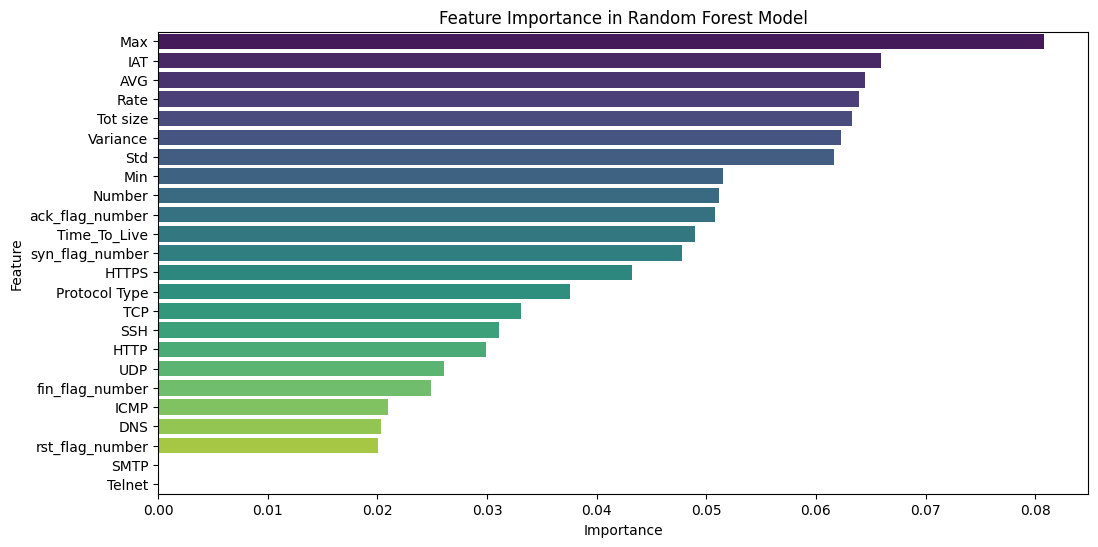

In [ ]:
# Get feature importances
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
feature_importances = feature_importances.sort_values(by="Importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importances["Importance"], y=feature_importances["Feature"], palette="viridis")
plt.title("Feature Importance in Random Forest Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

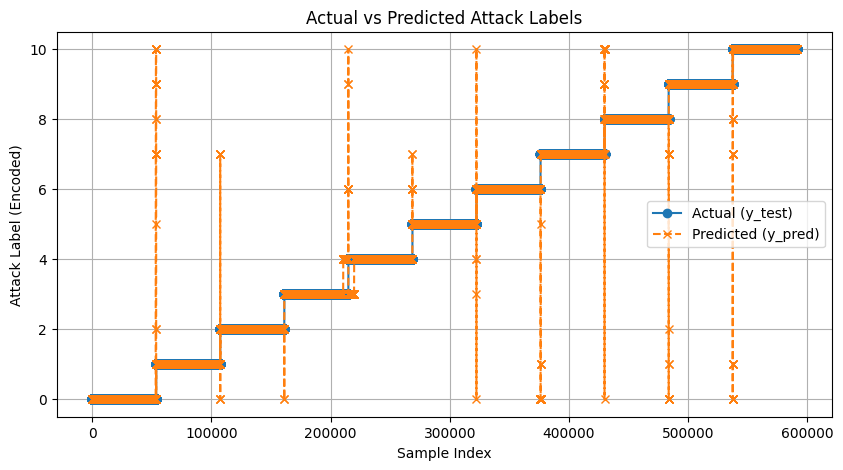

In [ ]:
# Sort values for better visualization
y_test_sorted, y_pred_sorted = zip(*sorted(zip(y_test, prediction_on_test_data)))

# Plot actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(y_test_sorted, label="Actual (y_test)", marker="o", linestyle="-")
plt.plot(y_pred_sorted, label="Predicted (y_pred)", marker="x", linestyle="--")

# Customize plot
plt.xlabel("Sample Index")
plt.ylabel("Attack Label (Encoded)")
plt.title("Actual vs Predicted Attack Labels")
plt.legend()
plt.grid(True)

# Show plot
plt.show()

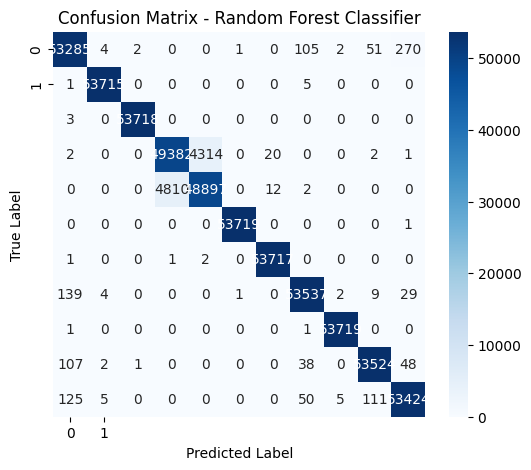

In [ ]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, prediction_on_test_data)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest Classifier")
plt.show()

#### XGBoost

In [ ]:
import xgboost as xgb

In [ ]:
# Create XGBoost classifier
xgb_clf = xgb.XGBClassifier(
    n_estimators=100,  # Number of trees
    learning_rate=0.1,  # Step size shrinkage
    max_depth=6,  # Tree depth
    objective='multi:softmax',  # Multi-class classification
    num_class=len(np.unique(y)),  # Number of classes
    eval_metric="mlogloss",  # Loss function
    use_label_encoder=False
)

In [ ]:
# Train the model
xgb_clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_class=11, num_parallel_tree=None, ...)

##### Predication and Testing

In [ ]:
# accuracy on train data
prediction_on_train_data=xgb_clf.predict(X_train)
accuracy_on_train_data=accuracy_score(y_train,prediction_on_train_data)
print("Accuracy on train data:",accuracy_on_train_data*100)

Accuracy on train data: 86.68924984748526


In [ ]:
# accuracy on test data
prediction_on_test_data=xgb_clf.predict(X_test)
accuracy_on_test_data=accuracy_score(y_test,prediction_on_test_data)
print("Accuracy on test data:",accuracy_on_test_data*100)

Accuracy on test data: 86.61695945522881


##### Visualization

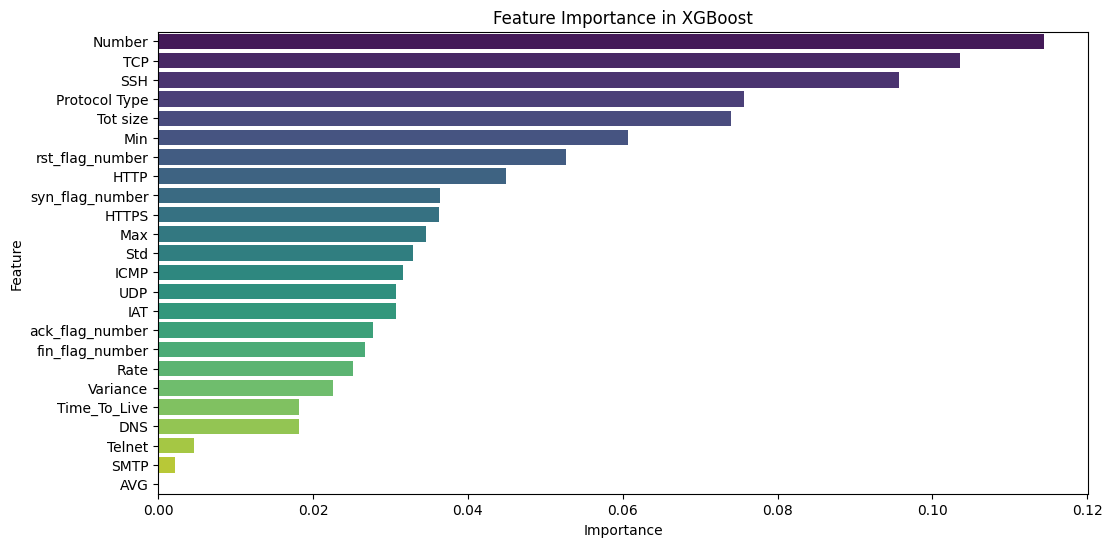

In [ ]:
# Get feature importances
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': xgb_clf.feature_importances_})
feature_importances = feature_importances.sort_values(by="Importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importances["Importance"], y=feature_importances["Feature"], palette="viridis")
plt.title("Feature Importance in XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


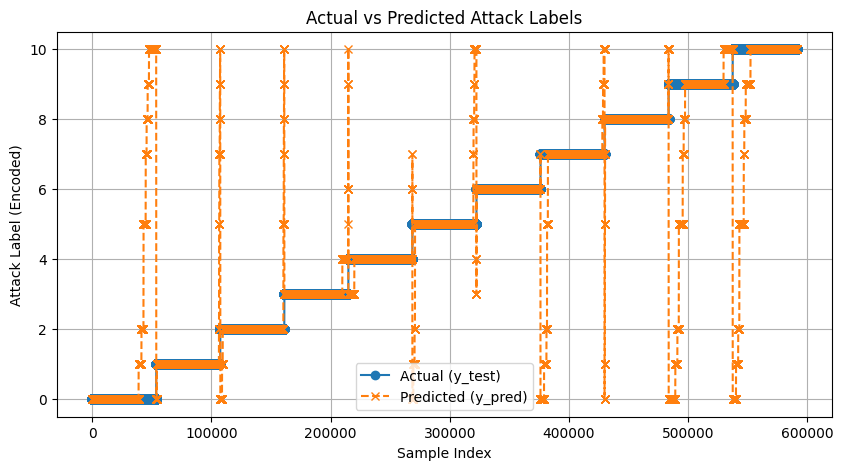

In [ ]:
# Sort values for better visualization
y_test_sorted, y_pred_sorted = zip(*sorted(zip(y_test, prediction_on_test_data)))

# Plot actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(y_test_sorted, label="Actual (y_test)", marker="o", linestyle="-")
plt.plot(y_pred_sorted, label="Predicted (y_pred)", marker="x", linestyle="--")

# Customize plot
plt.xlabel("Sample Index")
plt.ylabel("Attack Label (Encoded)")
plt.title("Actual vs Predicted Attack Labels")
plt.legend()
plt.grid(True)

# Show plot
plt.show()

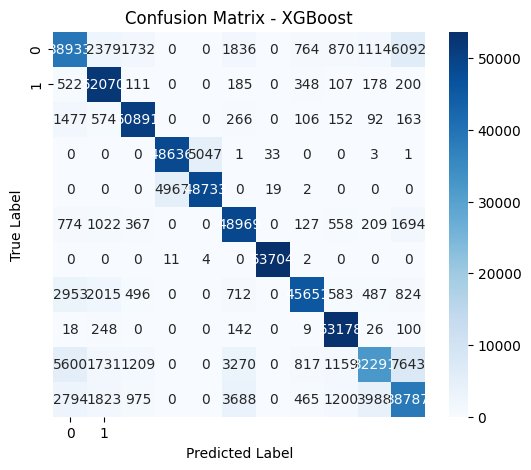

In [ ]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, prediction_on_test_data)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost")
plt.show()

#### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
log_reg = LogisticRegression()

In [ ]:
log_reg.fit(X_train, y_train)

LogisticRegression()

##### Prediction and Testing

In [ ]:
# accuracy on train data
prediction_on_train_data=log_reg.predict(X_train)
accuracy_on_train_data=accuracy_score(y_train,prediction_on_train_data)
print("Accuracy on train data:",accuracy_on_train_data*100)

Accuracy on train data: 17.36442687880811


In [ ]:
# accuracy on test data
prediction_on_test_data=log_reg.predict(X_test)
accuracy_on_test_data=accuracy_score(y_test,prediction_on_test_data)
print("Accuracy on test data:",accuracy_on_test_data*100)

Accuracy on test data: 17.30839849930702


##### Visualization

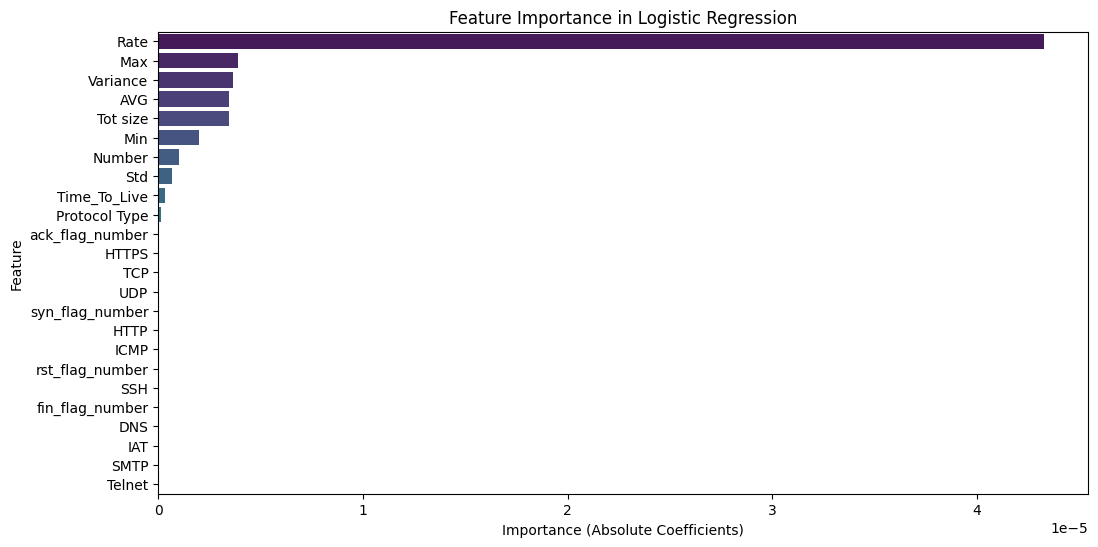

In [ ]:
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(log_reg.coef_).mean(axis=0)})
feature_importances = feature_importances.sort_values(by="Importance", ascending=False)

# Plot Feature Importance
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importances["Importance"], y=feature_importances["Feature"], palette="viridis")
plt.title("Feature Importance in Logistic Regression")
plt.xlabel("Importance (Absolute Coefficients)")
plt.ylabel("Feature")
plt.show()

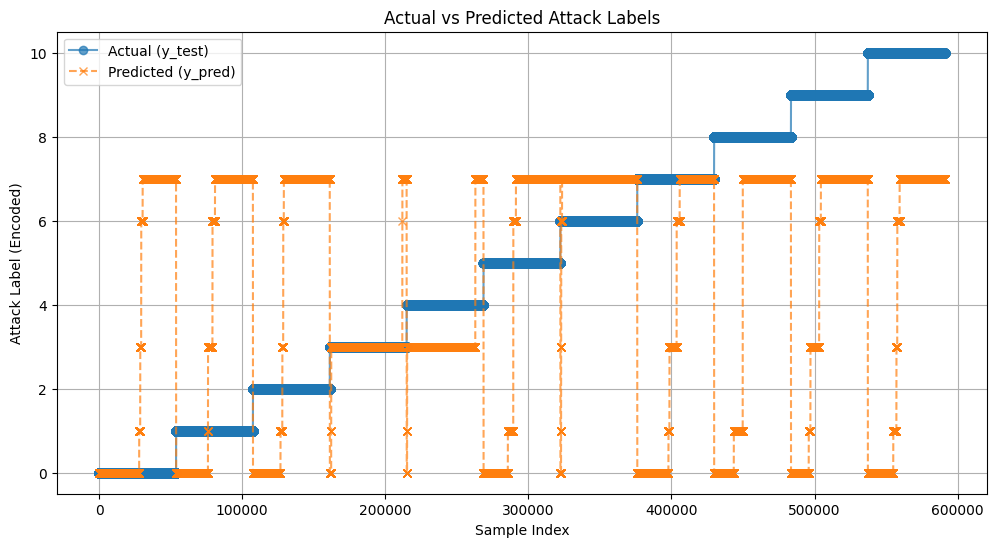

In [ ]:
# Sort actual and predicted values together for correct mapping
y_test_sorted, y_pred_sorted = zip(*sorted(zip(y_test, prediction_on_test_data)))

# Convert to list for plotting
y_test_sorted = list(y_test_sorted)
y_pred_sorted = list(y_pred_sorted)

# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test_sorted, label="Actual (y_test)", marker="o", linestyle="-", alpha=0.7)
plt.plot(y_pred_sorted, label="Predicted (y_pred)", marker="x", linestyle="--", alpha=0.7)

# Customize plot
plt.xlabel("Sample Index")
plt.ylabel("Attack Label (Encoded)")
plt.title("Actual vs Predicted Attack Labels")
plt.legend()
plt.grid(True)

# Show plot
plt.show()


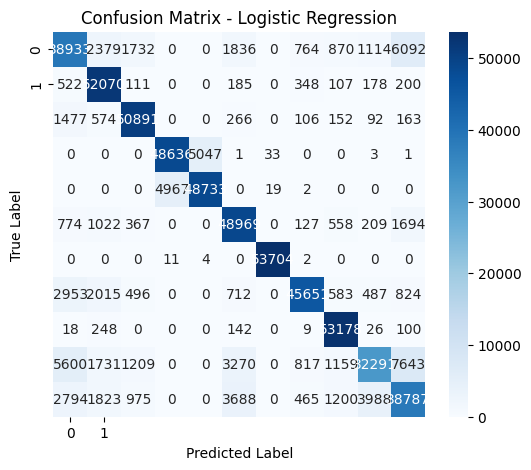

In [ ]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, prediction_on_test_data)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

#### Decision Tree


##### Prediction and Testing

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [ ]:
# Train Decision Tree Classifier
dt = DecisionTreeClassifier(max_depth=3, random_state=42)  # Limiting depth to avoid overfitting
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
# accuracy on train data
prediction_on_train_data=dt.predict(X_train)
accuracy_on_train_data=accuracy_score(y_train,prediction_on_train_data)
print("Accuracy on train data:",accuracy_on_train_data*100)

Accuracy on train data: 37.36217617588651


In [ ]:
# accuracy on test data
prediction_on_test_data=dt.predict(X_test)
accuracy_on_test_data=accuracy_score(y_test,prediction_on_test_data)
print("Accuracy on test data:",accuracy_on_test_data*100)

Accuracy on test data: 37.39057447028144


##### Visualization

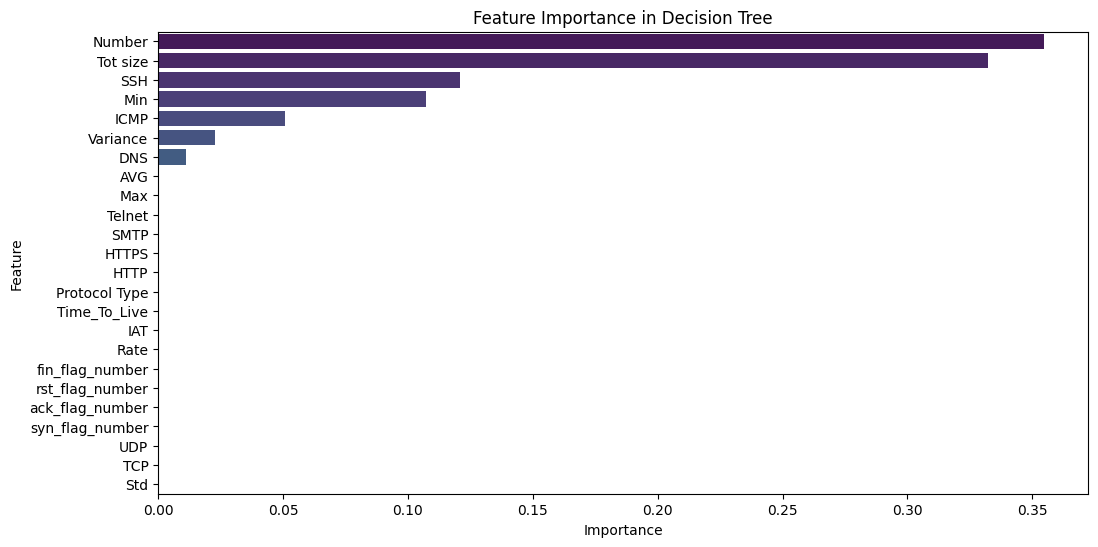

In [ ]:
# Get feature importances
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': dt.feature_importances_})
feature_importances = feature_importances.sort_values(by="Importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importances["Importance"], y=feature_importances["Feature"], palette="viridis")
plt.title("Feature Importance in Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


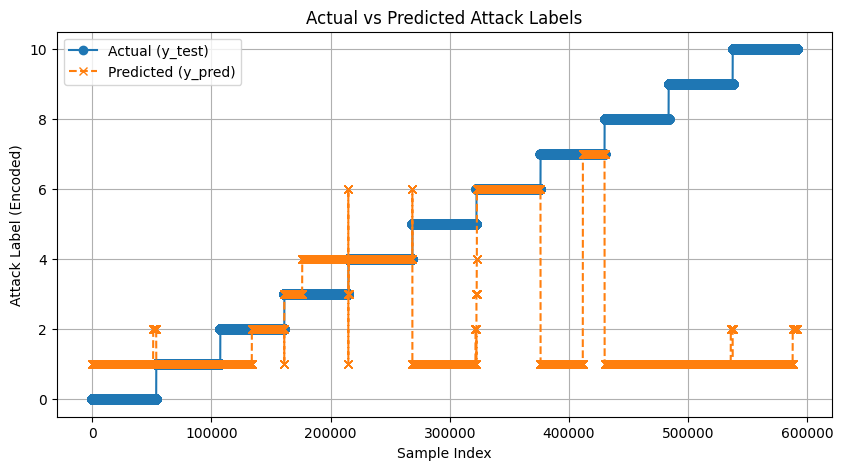

In [ ]:
# Sort values for better visualization
y_test_sorted, y_pred_sorted = zip(*sorted(zip(y_test, prediction_on_test_data)))

# Plot actual vs predicted values
plt.figure(figsize=(10, 5))
plt.plot(y_test_sorted, label="Actual (y_test)", marker="o", linestyle="-")
plt.plot(y_pred_sorted, label="Predicted (y_pred)", marker="x", linestyle="--")

# Customize plot
plt.xlabel("Sample Index")
plt.ylabel("Attack Label (Encoded)")
plt.title("Actual vs Predicted Attack Labels")
plt.legend()
plt.grid(True)

# Show plot
plt.show()

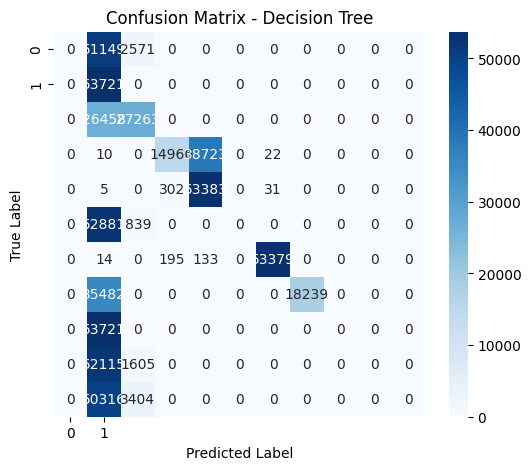

In [ ]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, prediction_on_test_data)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

### Model Comparison and Final Model Selection

**List Of Models**
- Random Forest Classifier
- XGBoost (XGBClassifier)
- Logistic Regression
- Decision Tree




| Model      | Training Accuracy | Testing Accuracy     |
| :---        |    :----:   |          ---: |
| Random Forest   | 99.70        | 98.25     |
| XGBoost   | 86.68        |86.61     |
| Logistic Regression   | 17.36        |17.30     |
| Decision Tree     | 37.36      |  37.39  |




**Observations on Model Performance**  

 1. **Random Forest Classifier**
   - achieved the highest accuracy (**98.25% testing accuracy**), making it the best-performing model with minimal overfitting.  
 2. **XGBoost**
   - performed moderately well (**86.61% accuracy**) but may benefit from hyperparameter tuning to enhance its performance.  
 3. **Logistic Regression**
   - performed **poorly (17.30% accuracy)**, indicating that the dataset is highly non-linear and not well-suited for this model.  
 4. **Decision Tree**
   - had **low accuracy (37.39%)**, suggesting it overfits the training data and lacks generalization.  

Overall, **Random Forest** is the best model for this dataset, while **Logistic Regression and Decision Tree are not suitable** for effective classification.






### Conclusion

- **Random Forest Classifier** achieved the highest accuracy (**98.25%**) with minimal overfitting, making it the most effective model.  
- **XGBoost** performed well but may require further optimization through hyperparameter tuning.  
- **Logistic Regression and Decision Tree** models showed poor performance, indicating the need for more advanced models for this dataset.  
- **For real-world deployment, Random Forest is recommended**, with potential improvements from XGBoost.  
- **To enhance intrusion detection**, continuous monitoring, model updates, and feature engineering should be prioritized to adapt to evolving cyber threats.  


### Final Reccomendation

- **Adopt Random Forest Classifier** as the primary intrusion detection model due to its **high accuracy (98.25%)** and reliability.  
- **Optimize XGBoost** with hyperparameter tuning to enhance its performance for future improvements.  
- **Avoid using Logistic Regression and Decision Tree** as they show significantly low accuracy and are not suitable for complex cybersecurity data.  
- **Continuously update models** with new threat data to maintain effectiveness against evolving cyber threats.  
- **Enhance feature engineering** to improve detection capabilities and reduce false positives.  



### Business Reccomendation

- **Implement Random Forest Classifier** in the cybersecurity framework to enhance intrusion detection efficiency.  
- **Invest in AI-driven security solutions** to strengthen defenses against evolving cyber threats.  
- **Regularly update and retrain models** with the latest attack patterns to maintain high detection accuracy.  
- **Optimize computational resources** by fine-tuning models like XGBoost to balance performance and efficiency.  
- **Integrate cybersecurity insights into decision-making** to proactively mitigate potential threats and reduce operational risks.  


### Research Question and Answers

###### RQ-1 How does the performance of intrusion detection systems compare to traditional cybersecurity approaches in detecting and mitigating cyber threats?

**Comparison of Intrusion Detection Systems (IDS) vs. Traditional Cybersecurity Approaches**

| Feature | **Intrusion Detection Systems (IDS)** | **Traditional Cybersecurity Approaches** |
|---------|--------------------------------------|-----------------------------------------|
| **Detection Capability** | Uses **signature-based** (known attack patterns) and **anomaly-based** (deviation from normal behavior) detection. | Primarily **signature-based** (firewalls, antivirus) which may struggle with unknown threats. |
| **Threat Response** | **Passive (IDS)**: Detects threats but does not prevent them. <br> **Active (IPS - Intrusion Prevention System)**: Can block malicious activity. | **Reactive**—requires manual intervention after an attack is detected. |
| **Detection of Zero-Day Attacks** | **Anomaly-based IDS** can identify suspicious activity that does not match known threats. | Limited ability—traditional methods rely on known attack signatures and may fail to detect new threats. |
| **Network Monitoring** | Continuously monitors network traffic and logs suspicious activities. | Firewalls and antivirus software provide **perimeter security**, but may not detect **internal threats**. |
| **Machine Learning Integration** | Many modern IDS use **AI and ML** to improve anomaly detection and reduce false positives. | Traditional methods typically do not incorporate AI, making them less adaptive. |
| **Scalability & Automation** | Can handle large-scale network traffic and adapt to evolving threats. | Often requires manual updates and human monitoring, making it less scalable. |
| **False Positives & Negatives** | Anomaly-based IDS may generate **high false positives**, requiring tuning. | Signature-based methods have **fewer false positives** but higher **false negatives** (missing new threats). |

**Key Takeaways**
- **IDS offers superior real-time threat detection** compared to traditional cybersecurity tools.
- **Traditional methods (firewalls, antivirus)** provide **first-line defense** but struggle with sophisticated or **zero-day attacks**.
- **AI-powered IDS** can learn and adapt to new threats, making them **more effective in modern cybersecurity**.


#### RQ-2 What are the strengths and limitations of machine learning and deep learning algorithms in accurately identifying anomalous activities and potential security breaches?


**Strengths and Limitations of Machine Learning & Deep Learning in Cybersecurity**

**Strengths**
1. **Automated Threat Detection**  
   - ML and DL models can analyze vast amounts of network traffic and identify threats **without human intervention**.

2. **Detection of Zero-Day Attacks**  
   - **Anomaly-based models** can recognize deviations from normal behavior, making them effective against **previously unseen attacks**.

3. **Adaptive Learning**  
   - Machine learning models can **continuously improve** by learning from new attack patterns, reducing reliance on pre-defined rules.

4. **Real-Time Analysis**  
   - Deep learning models (e.g., CNNs, RNNs) can **process security logs and network traffic in real time**, improving response time to threats.

5. **Reduction in False Positives**  
   - Advanced models, especially **deep learning-based**, can differentiate between **benign and malicious activities**, reducing **false alarms**.

6. **Handling Complex Data**  
   - Deep learning models (e.g., LSTMs, Autoencoders) excel at analyzing **high-dimensional data** like network packets, user behaviors, and system logs.

**Limitations**
1. **High Computational Cost**  
   - Deep learning models require **significant computational resources**, making them costly and sometimes impractical for real-time cybersecurity applications.

2. **Data Dependency**  
   - The performance of ML/DL models **heavily depends on the quality and diversity of training data**. Poor datasets may lead to inaccurate predictions.

3. **Vulnerability to Adversarial Attacks**  
   - Attackers can manipulate input data (e.g., **adversarial examples**) to **bypass detection** systems, tricking the model into misclassifying threats.

4. **Lack of Explainability**  
   - Deep learning models, especially **neural networks**, act as **black boxes**, making it difficult to interpret why a certain activity was flagged as an attack.

5. **Overfitting to Training Data**  
   - If a model is trained on a **limited dataset**, it may fail to generalize to real-world scenarios, leading to **poor detection of novel threats**.

6. **Need for Continuous Updating**  
   - Cyber threats evolve rapidly, requiring **constant model retraining** and updates to remain effective.

**Conclusion**
Machine learning and deep learning provide **powerful capabilities** for **anomaly detection and cybersecurity**. However, their **effectiveness depends on quality data, computational resources, and robust security against adversarial attacks**. Hybrid approaches, combining **traditional rule-based** methods with **AI-driven detection**, can provide **the best security outcomes**.


#### RQ-3 How do ML cybersecurity solutions demonstrate adaptability and scalability when deployed in real-world CPS environments, and what are the key factors influencing their effectiveness?

**Adaptability and Scalability of ML Cybersecurity Solutions in CPS Environments**

**Adaptability in Real-World CPS Environments**
Machine Learning (ML)-based cybersecurity solutions demonstrate adaptability in **Cyber-Physical Systems (CPS)** by:

1. **Self-Learning Capabilities**  
   - ML models can adapt to evolving threats by continuously learning from **new attack patterns and system behaviors**.

2. **Behavioral Analysis Over Static Rules**  
   - Unlike traditional rule-based security, ML models identify **anomalous behavior patterns**, making them effective against **zero-day attacks**.

3. **Context-Aware Decision Making**  
   - Advanced AI-driven cybersecurity solutions analyze **real-time system context**, adjusting security measures dynamically based on the operational environment.

4. **Integration with Diverse Data Sources**  
   - CPS environments generate **heterogeneous data** (e.g., sensor logs, network traffic, user activities). ML models can process and correlate **multi-modal data** to enhance threat detection.

5. **Edge & Cloud-Based Adaptation**  
   - ML-based security solutions can operate at both the **edge (real-time threat detection)** and the **cloud (scalable model updates and training)** for continuous improvements.

**Scalability in Large-Scale CPS Deployments**
ML-based security solutions ensure scalability through:

1. **Distributed Processing & Federated Learning**  
   - Federated learning enables ML models to **train on multiple CPS devices** without centralizing data, reducing bandwidth and enhancing scalability.

2. **Cloud-Native Deployment**  
   - Cloud-based ML models leverage **elastic computing resources**, allowing real-time monitoring and large-scale threat analysis across multiple CPS nodes.

3. **Incremental Learning**  
   - Online learning techniques allow models to **adapt incrementally** to new data without retraining from scratch, reducing computational overhead.

4. **Automated Model Retraining & Deployment**  
   - ML Ops frameworks automate model retraining, validation, and deployment, ensuring seamless **updates without service disruption**.

5. **Hierarchical Intrusion Detection Systems (H-IDS)**  
   - Multi-layered security models distribute ML processing across **local, regional, and global levels**, balancing **real-time efficiency** and **comprehensive threat analysis**.

**Key Factors Influencing Effectiveness**
1. **Data Quality & Diversity**  
   - High-quality, **diverse datasets** improve ML model generalization, reducing false positives and negatives.

2. **Robust Feature Engineering**  
   - Extracting meaningful features from CPS logs, network traffic, and sensor data enhances detection accuracy.

3. **Model Robustness Against Adversarial Attacks**  
   - Implementing **adversarial training** and **defensive mechanisms** improves resilience against **evasion and poisoning attacks**.

4. **Computational Efficiency**  
   - Lightweight ML models (e.g., **pruned deep learning models**) enhance performance for **real-time CPS applications**.

5. **Regulatory Compliance & Security Policies**  
   - Ensuring ML cybersecurity aligns with **industry standards (NIST, ISO 27001)** enhances adoption in real-world CPS.

**Conclusion**
ML-powered cybersecurity solutions offer **high adaptability and scalability** in **real-world CPS environments**, enabling **dynamic, real-time, and large-scale threat detection**.